In [1]:
# Celda 1: Generación del Espacio de Estados y Cálculo
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

# Pesos estructurales del sistema B.L.A.S.T
PESOS = np.array([0.30, 0.25, 0.15, 0.10, 0.20]) # P0, P1, P2, P3, P4
CONST_NT_EXP = 1.54
SCALING_ORIGINAL = 0.2125
SCALING_PROPUESTO = 0.2833

# Espacio de valores escalares efectivos (Dir * Fuerza)
valores_x = [-2, -1, 0, 1, 2]
espacio_estados = list(itertools.product(valores_x, repeat=5))

datos = []
for estado in espacio_estados:
    # Producto punto de la matriz de estados por sus pesos, dividido entre la constante de normalización
    x_array = np.array(estado)
    i_cd = np.dot(x_array, PESOS) / 2.0
    
    # Determinación de sesgo del mercado
    if abs(i_cd) < 0.26:
        bias = "Neutral"
    elif i_cd >= 0.26:
        bias = "Bullish"
    else:
        bias = "Bearish"
        
    # Función de transformación Softmax variante
    def calcular_probabilidades(calc_edge, scaling_factor):
        e_l = np.exp(calc_edge * scaling_factor)
        e_s = np.exp(-calc_edge * scaling_factor)
        e_nt = np.exp(CONST_NT_EXP)
        total = e_l + e_s + e_nt
        return e_l/total, e_s/total, e_nt/total

    l_orig, s_orig, nt_orig = calcular_probabilidades(i_cd, SCALING_ORIGINAL)
    l_prop, s_prop, nt_prop = calcular_probabilidades(i_cd, SCALING_PROPUESTO)
    
    datos.append({
        "P0": estado[0], "P1": estado[1], "P2": estado[2], "P3": estado[3], "P4": estado[4],
        "I_CD": i_cd,
        "Market_Bias": bias,
        "L_Orig": l_orig, "S_Orig": s_orig, "NT_Orig": nt_orig,
        "L_Prop": l_prop, "S_Prop": s_prop, "NT_Prop": nt_prop,
        "Delta_L": l_prop - l_orig,
        "Delta_S": s_prop - s_orig,
        "Delta_NT": nt_prop - nt_orig
    })

df = pd.DataFrame(datos)

# Restringir salidas numéricas de coma flotante
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print(f"Total de iteraciones calculadas: {len(df)}")

Total de iteraciones calculadas: 3125


In [2]:
# Celda 2: Análisis Estadístico de la Divergencia
print("\n--- Descriptivos del Modelo ---")
print(df[['I_CD', 'L_Orig', 'L_Prop', 'Delta_L', 'Delta_NT']].describe())

# Identificación de los extremos operacionales
print("\n--- Escenario de Máxima Convicción Bullish (I_CD = 1.0) ---")
print(df[df['I_CD'] == df['I_CD'].max()][['I_CD', 'Market_Bias', 'L_Orig', 'L_Prop', 'NT_Orig', 'NT_Prop']].head(1))

print("\n--- Escenario de Máxima Convicción Bearish (I_CD = -1.0) ---")
print(df[df['I_CD'] == df['I_CD'].min()][['I_CD', 'Market_Bias', 'S_Orig', 'S_Prop', 'NT_Orig', 'NT_Prop']].head(1))

print("\n--- Impacto Estructural por Clasificación de Sesgo ---")
print(df.groupby('Market_Bias')[['Delta_L', 'Delta_S', 'Delta_NT']].mean())


--- Descriptivos del Modelo ---
           I_CD    L_Orig    L_Prop   Delta_L  Delta_NT
count 3125.0000 3125.0000 3125.0000 3125.0000 3125.0000
mean    -0.0000    0.1503    0.1505    0.0002   -0.0004
std      0.3355    0.0107    0.0143    0.0036    0.0005
min     -1.0000    0.1205    0.1117   -0.0088   -0.0037
25%     -0.2250    0.1430    0.1407   -0.0023   -0.0006
50%      0.0000    0.1500    0.1500    0.0000   -0.0002
75%      0.2250    0.1573    0.1598    0.0025   -0.0000
max      1.0000    0.1843    0.1968    0.0125    0.0000

--- Escenario de Máxima Convicción Bullish (I_CD = 1.0) ---
       I_CD Market_Bias  L_Orig  L_Prop  NT_Orig  NT_Prop
3124 1.0000     Bullish  0.1843  0.1968   0.6952   0.6915

--- Escenario de Máxima Convicción Bearish (I_CD = -1.0) ---
     I_CD Market_Bias  S_Orig  S_Prop  NT_Orig  NT_Prop
0 -1.0000     Bearish  0.1843  0.1968   0.6952   0.6915

--- Impacto Estructural por Clasificación de Sesgo ---
             Delta_L  Delta_S  Delta_NT
Market_Bias     

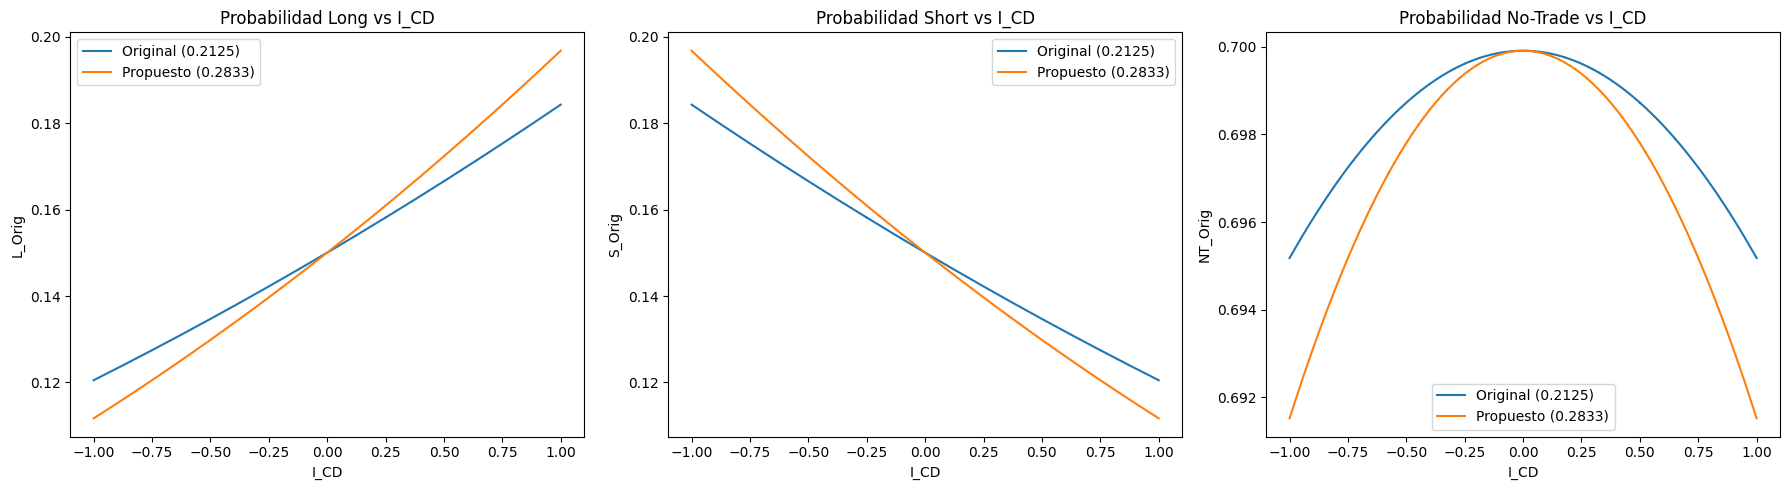

In [3]:
# Celda 3: Visualización de la Desviación del Modelo
# (Opcional si requieres renderizar las curvas de distribución probabilística)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(data=df, x='I_CD', y='L_Orig', label='Original (0.2125)', ax=axes[0])
sns.lineplot(data=df, x='I_CD', y='L_Prop', label='Propuesto (0.2833)', ax=axes[0])
axes[0].set_title('Probabilidad Long vs I_CD')

sns.lineplot(data=df, x='I_CD', y='S_Orig', label='Original (0.2125)', ax=axes[1])
sns.lineplot(data=df, x='I_CD', y='S_Prop', label='Propuesto (0.2833)', ax=axes[1])
axes[1].set_title('Probabilidad Short vs I_CD')

sns.lineplot(data=df, x='I_CD', y='NT_Orig', label='Original (0.2125)', ax=axes[2])
sns.lineplot(data=df, x='I_CD', y='NT_Prop', label='Propuesto (0.2833)', ax=axes[2])
axes[2].set_title('Probabilidad No-Trade vs I_CD')

plt.tight_layout()
plt.show()